In [2]:
# libraries for part 1
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
import re
import sys

pd.set_option('display.max_columns', 200)
plt.style.use("ggplot")

# Libraries for part 2
from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

# libraries part bert
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaTokenizer, RobertaModel

In [ ]:
df = pd.read_csv('temp.csv').iloc[:20000,1:]
df

,isfake,title
0,0,Plus one article on Google Plus(Thanks to Ali ...
1,1,The Cost Of The Best Senate Banking Committee ...
2,0,WHEN Julia Geist was asked to draw a picture o...
3,1,– 100 Compiled Studies on Vaccine Dangers (Act...
4,0,IF YOU SPEND the majority of your waking hours...
...,...,...
19995,0,"Skarstedt Gallery20 East 79th Street, Manhatta..."
19996,1,Of the many concerns surrounding the dominance...
19997,1,Getty Hungarian Prime Minister says Europe can...
19998,1,"The Toffees manager said: ""Clearly he is a pla..."


In [10]:
class TitleDataset(Dataset):
    def __init__(self, df):
        self.titles = df['title'].astype('str').fillna('no title')
        self.targets = df['isfake']

    def __len__(self):
        return len(self.titles)

    def __getitem__(self, idx):
        return self.titles.iloc[idx], self.targets.iloc[idx]

class RobertaClassifier(nn.Module):
    def __init__(self, bertmodel='roberta-base'):
        super().__init__()
        self.tokenizer = RobertaTokenizer.from_pretrained(bertmodel)
        self.encoder = RobertaModel.from_pretrained(bertmodel)
        self.fc1 = nn.Linear(self.encoder.config.hidden_size, 128)
        self.fc2 = nn.Linear(128,32)
        self.fc3 = nn.Linear(32,16)
        self.fc4 = nn.Linear(16,1)

    def mean_pooling(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        token_embs = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(token_embs.size()).float()
        vectors = (token_embs * mask).sum(1) / mask.sum(1)
        return vectors

    def forward(self, inputs):
        x = self.mean_pooling(inputs['input_ids'], inputs['attention_mask'])
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x.float()

    def predict(self, outputs):
        return (outputs > 0).float().squeeze(-1)

In [18]:
model = RobertaClassifier()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device cuda.
Epoch: 3/3, Batch: 625/625, Loss: 0.0100, Avg: 0.0427, Acc: 1.0000

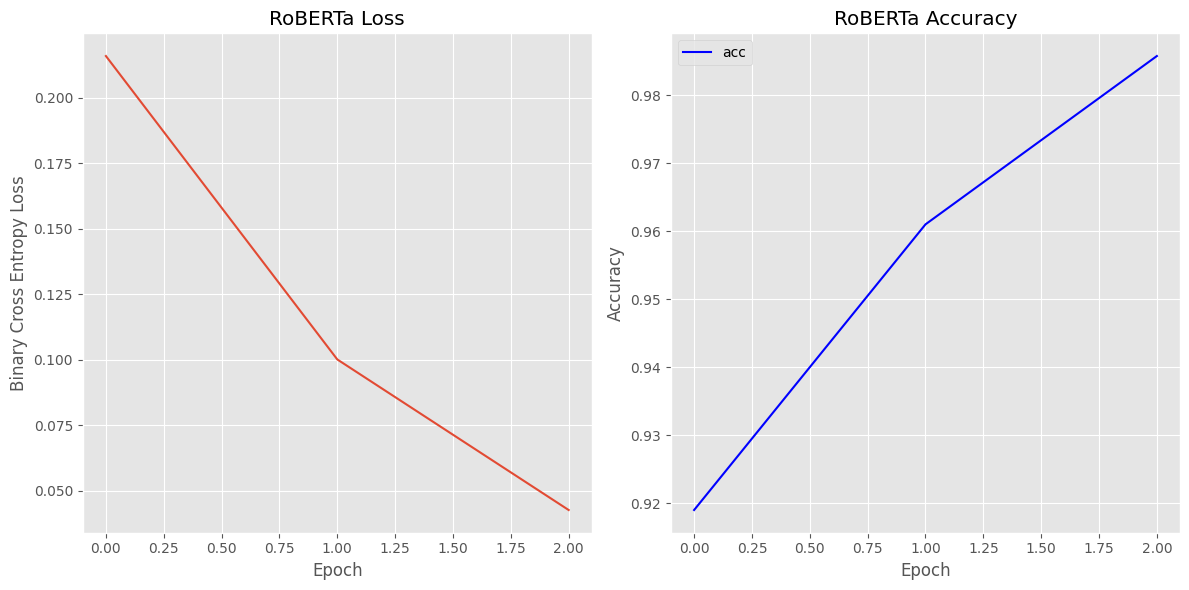

In [21]:
# training loop
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW([
    {'params': model.encoder.parameters(), 'lr': 2e-5},
    {'params': model.fc1.parameters(), 'lr': 1e-4},
    {'params': model.fc2.parameters(), 'lr': 1e-4},
    {'params': model.fc3.parameters(), 'lr': 1e-4},
    {'params': model.fc4.parameters(), 'lr': 1e-5},
])
dataset = TitleDataset(df)
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

epochs = 2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device {device}.')
model.to(device)
losses = []
accs = []
    
for e in range(epochs):
    running_loss = 0
    running_acc = 0
    for idx,(titles,labels) in enumerate(loader):
        inputs = model.tokenizer(list(titles), padding=True, truncation=True, max_length=128, return_tensors='pt')
        inputs = {k:v.to(device) for k,v in inputs.items()}

        optimizer.zero_grad()

        preds = model.forward(inputs)
        loss = criterion(preds, labels.float().unsqueeze(-1).to(device))
        loss.backward()

        optimizer.step()

        pred_labels = model.predict(preds)
        acc = float((pred_labels == labels.to(device)).float().mean())
        
        running_loss += loss.item()
        running_acc += acc
        sys.stdout.write(f'\rEpoch: {e+1}/{epochs}, Batch: {idx+1}/{len(loader)}, Loss: {loss.item():.4f}, Avg: {running_loss/(idx+1):.4f}, Acc: {acc:.4f}')
        losses.append(running_loss/(idx+1))
        accs.append(running_acc/(idx+1))

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(losses, label='loss')
plt.xlabel('Batch')
plt.ylabel('Binary Cross Entropy Loss')
plt.title('RoBERTa Loss')
plt.legend
plt.subplot(1,2,2)
plt.plot(accs, label='acc', color='blue')
plt.xlabel('Batch')
plt.ylabel('Accuracy')
plt.title('RoBERTa Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# read in data
df_test = pd.read_csv('temp.csv').iloc[20000:25000,1:]
df_test

,isfake,title
20000,1,How Manchester United could look with Naby Kei...
20001,0,On the same day he filed a Federal Election Co...
20002,0,"At almost every turn, he was grudging toward M..."
20003,1,Greener Living: Energy Saving Begins at HomeHe...
20004,1,Desperate times require desperate measures – a...
...,...,...
24995,0,He peels the onion to the next-to-last layer w...
24996,1,Huawei Nova 2i Officially Priced in the Philip...
24997,1,The Navajo Skinwalker(Before It's News)As frie...
24998,0,We get it: you like to have control of your ow...


In [25]:
test_example = pd.DataFrame({'isfake':[1], 'title':['isreal declares random goat as the 1234 new prime minister of chicago']})

df_test_with_example = pd.concat([df_test, test_example], axis=0)
df_test_with_example.tail()

,isfake,title
24996,1,Huawei Nova 2i Officially Priced in the Philip...
24997,1,The Navajo Skinwalker(Before It's News)As frie...
24998,0,We get it: you like to have control of your ow...
24999,0,Let me start by getting this out of the way: I...
0,1,isreal declares random goat as the 1234 new pr...


Batch: 50/50, Loss: 0.2047, Avg: 0.5342, Acc: 0.9400. F1: 0.9348
Mean BCE Loss: 0.2872
Mean Accuracy: 0.9226
Mean F1: 0.9131
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2778
           1       0.90      0.93      0.91      2222

    accuracy                           0.92      5000
   macro avg       0.92      0.92      0.92      5000
weighted avg       0.92      0.92      0.92      5000



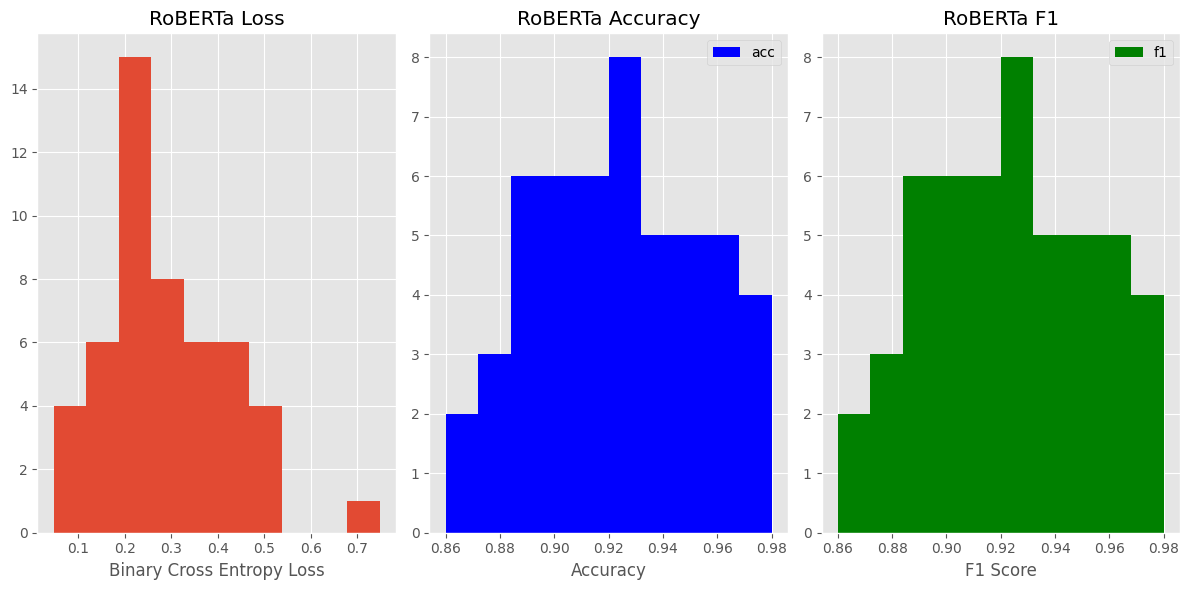

In [30]:
testset = TitleDataset(df_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=0)

with torch.no_grad():
    losses = []
    accs = []
    f1s = []
    total_preds = []
    total_labels = []
    for idx,(titles,labels) in enumerate(testloader):
        inputs = model.tokenizer(list(titles), padding=True, truncation=True, max_length=64, return_tensors='pt')
        inputs = {k:v.to(device) for k,v in inputs.items()}

        preds = model.forward(inputs)
        loss = criterion(preds, labels.float().unsqueeze(-1).to(device))

        pred_labels = (preds > 0).float().squeeze(-1)

        total_labels += [int(l) for l in labels]
        total_preds += [int(p) for p in pred_labels]

        acc = float((pred_labels == labels.to(device)).float().mean())
        f1 = f1_score(pred_labels.cpu().numpy(), labels.to(device).cpu().numpy())

        
        losses += [loss.item()]
        accs += [acc]
        f1s += [f1]
        sys.stdout.write(f'\rBatch: {idx+1}/{len(testloader)}, Loss: {loss.item():.4f}, Avg: {running_loss/(idx+1):.4f}, Acc: {acc:.4f}. F1: {f1:.4f}')


print(f'\nMean BCE Loss: {np.mean(losses):.4f}')
print(f'Mean Accuracy: {np.mean(accs):.4f}')
print(f'Mean F1: {np.mean(f1s):.4f}')
print(classification_report(total_preds, total_labels))



plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.hist(losses, label='loss')
plt.xlabel('Binary Cross Entropy Loss')
plt.title('RoBERTa Loss')
plt.legend
plt.subplot(1,3,2)
plt.hist(accs, label='acc', color='blue')
plt.xlabel('Accuracy')
plt.title('RoBERTa Accuracy')
plt.legend()
plt.subplot(1,3,3)
plt.hist(accs, label='f1', color='green')
plt.xlabel('F1 Score')
plt.title('RoBERTa F1')
plt.legend()
plt.tight_layout()
plt.show()